🔍 Found 5 high-prominence peaks.


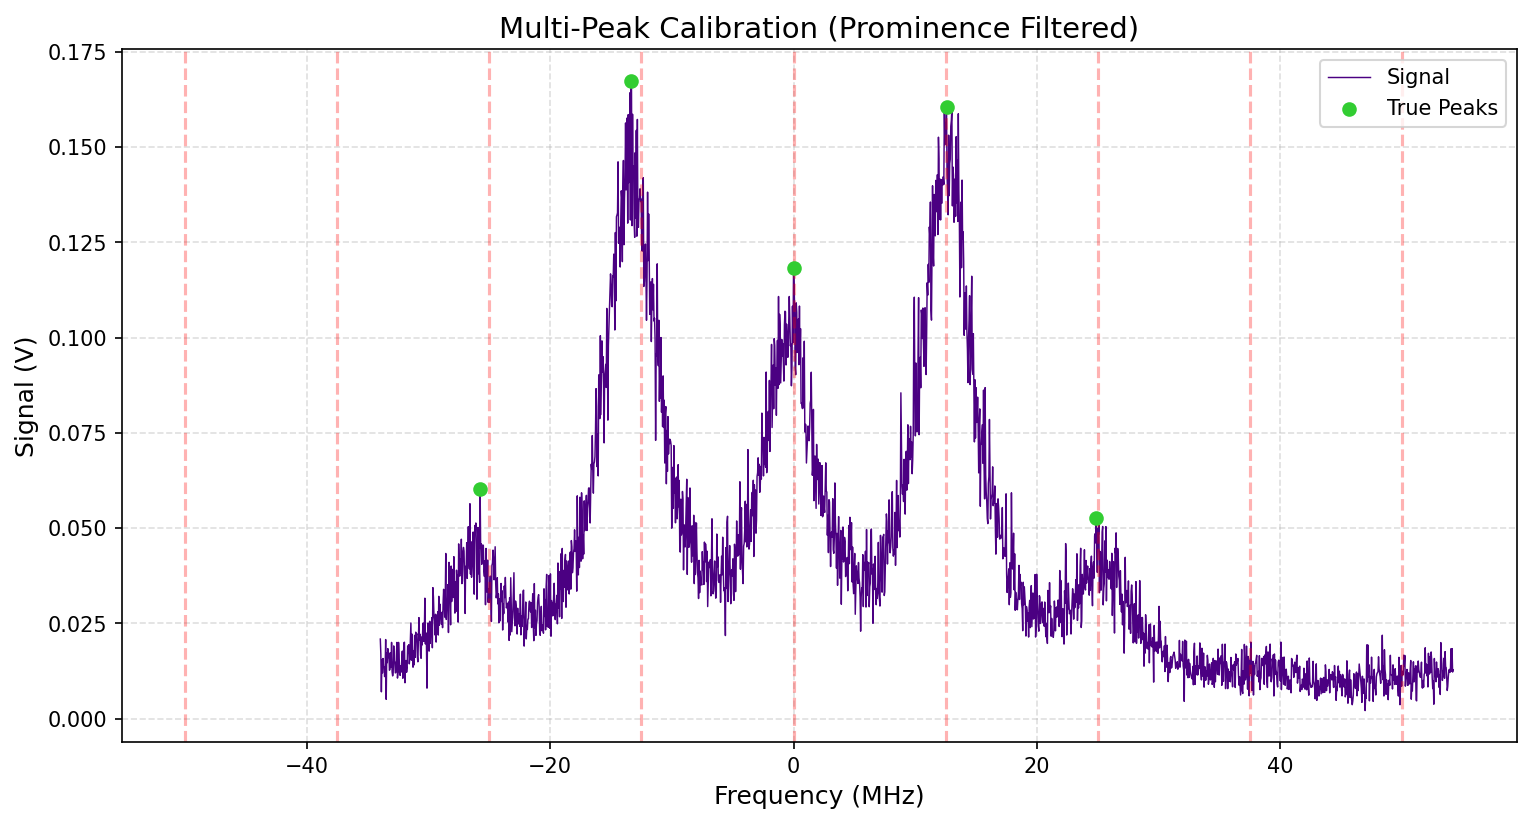

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from pathlib import Path

# --- LOAD DATA ---
data_dir = Path("/Users/michelangelodondi/Documents/Research/rb6s-spectroscopy/data/01_raw/power_eom")
f = data_dir / "4121nm_eom_after1.csv"
df = pd.read_csv(f, skiprows=2, header=None)
df.columns = ['time_s', 'signal_v']
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# --- THE WINNING PARAMETERS ---
peaks, props = find_peaks(df['signal_v'], prominence=0.03, distance=200)

t_peaks = df['time_s'].iloc[peaks].values
v_peaks = df['signal_v'].iloc[peaks].values

# Sort peaks by time to ensure correct left-to-right order
sort_idx = np.argsort(t_peaks)
t_peaks = t_peaks[sort_idx]
v_peaks = v_peaks[sort_idx]

print(f"✅ Successfully locked onto {len(t_peaks)} main peaks.")

# --- PRECISION CALIBRATION ---
if len(t_peaks) == 5:
    # With exactly 5 peaks, the 3rd one (index 2) is the central carrier
    center_idx = 2 
    t_zero = t_peaks[center_idx]
    
    # Calculate the average spacing between adjacent peaks
    spacings = np.diff(t_peaks)
    avg_spacing = np.median(spacings)
    
    # Calculate Scan Rate (MHz per second)
    mhz_per_s = 12.5 / avg_spacing
    
    # Apply calibration to the entire dataset
    df['freq_mhz'] = (df['time_s'] - t_zero) * mhz_per_s
    
    # Plotting
    plt.figure(figsize=(12, 6), dpi=150)
    plt.plot(df['freq_mhz'], df['signal_v'], color='indigo', linewidth=1.2, label='Raw Signal')
    
    # Mark the detected peaks
    plt.scatter((t_peaks - t_zero) * mhz_per_s, v_peaks, color='limegreen', zorder=5, s=60, label='Detected Peaks')

    # Draw the theoretical 12.5 MHz grid
    for i in range(-2, 3):
        plt.axvline(i * 12.5, color='red', linestyle='--', alpha=0.4)

    plt.title(f"Calibrated 5-Peak Spectrum (Scan Rate: {mhz_per_s:.2f} MHz/s)", fontsize=14)
    plt.xlabel("Frequency relative to Carrier (MHz)", fontsize=12)
    plt.ylabel("Signal (V)", fontsize=12)
    
    # Zoom in to properly frame the 5 peaks
    plt.xlim(-35, 35) 
    
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()
    plt.show()
else:
    print(f"Found {len(t_peaks)} peaks. Expected exactly 5 based on your last test.")